<a href="https://colab.research.google.com/github/Dharshini13002/Deep-learning-codes-of-FER/blob/main/guidetransformercode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

In [ ]:
# Kaggle API setup
os.environ["KAGGLE_USERNAME"] = "tspradeepkumar"  # Replace with your Kaggle username
os.environ["KAGGLE_KEY"] = "740d0138672a033f5e2020390c3cb021"  # Replace with your Kaggle API key

In [ ]:
from kaggle.api.kaggle_api_extended import KaggleApi

In [ ]:
# Enable CuDNN benchmarking for performance
cudnn.benchmark = True
plt.ion()  # Enable interactive mode for matplotlib

In [ ]:
# Download Hymenoptera dataset from Kaggle if not already present
data_dir = '/content/hymenoptera/hymenoptera'
if not os.path.exists(os.path.join(data_dir, 'train')):
    print("Downloading Hymenoptera dataset from Kaggle...")
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files('thedatasith/hymenoptera', path=data_dir, unzip=True)
    print("Dataset downloaded and extracted.")
else:
    print("Hymenoptera dataset already exists.")

Hymenoptera dataset already exists.


In [ ]:
# Data transformations for training and validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}


In [ ]:
# Load datasets and create dataloaders
image_datasets = {
    x: datasets.ImageFolder(root=os.path.join(data_dir, x), transform=data_transforms[x])
    for x in ['train', 'val']
}

dataloaders = {
    x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                   shuffle=True, num_workers=0)  # Use 0 for Colab/Windows
    for x in ['train', 'val']
}

dataset_sizes = {
    x: len(image_datasets[x]) for x in ['train', 'val']
}

class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [ ]:
# Helper to show images
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)


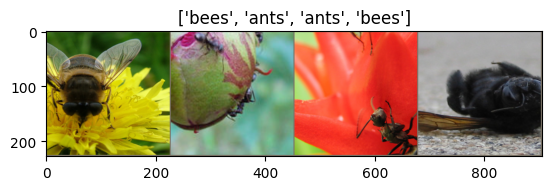

In [ ]:
# Show a batch of training data
inputs, classes = next(iter(dataloaders['train']))
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

In [ ]:
# Training function
def train_model(model, criterion, optimizer, scheduler, num_epochs=5):
    since = time.time()
    with TemporaryDirectory() as tempdir:
        best_model_path = os.path.join(tempdir, 'best_model.pt')
        torch.save(model.state_dict(), best_model_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)
            for phase in ['train', 'val']:
                model.train() if phase == 'train' else model.eval()
                running_loss = 0.0
                running_corrects = 0

                for inputs, labels in dataloaders[phase]:
                    inputs, labels = inputs.to(device), labels.to(device)
                    optimizer.zero_grad()

                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)

                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_path)
            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:.4f}')
        model.load_state_dict(torch.load(best_model_path))
    return model


In [ ]:
# Visualization of model predictions
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images // 2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'Predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)


In [ ]:
# Predict a single image
def visualize_model_predictions(model, img_path):
    model.eval()
    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)
        plt.figure()
        plt.title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])


In [ ]:
# Load pretrained ResNet18 and modify for binary classification
model_conv = models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)
model_conv = model_conv.to(device)

In [ ]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [ ]:
# Train the model
model_conv = train_model(model_conv, criterion, optimizer_conv, exp_lr_scheduler, num_epochs=5)


Epoch 0/4
----------
train Loss: 0.6622 Acc: 0.6230
val Loss: 0.2932 Acc: 0.8824

Epoch 1/4
----------
train Loss: 0.3293 Acc: 0.8730
val Loss: 0.2046 Acc: 0.9346

Epoch 2/4
----------
train Loss: 0.4398 Acc: 0.8033
val Loss: 0.1872 Acc: 0.9346

Epoch 3/4
----------
train Loss: 0.4427 Acc: 0.7869
val Loss: 0.1796 Acc: 0.9542

Epoch 4/4
----------
train Loss: 0.4258 Acc: 0.8238
val Loss: 0.1557 Acc: 0.9477

Training complete in 0m 19s
Best val Acc: 0.9542


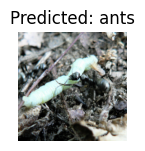

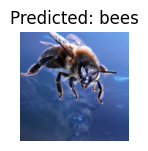

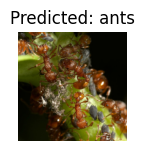

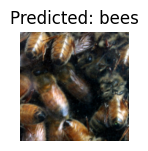

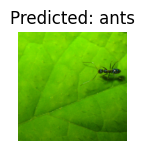

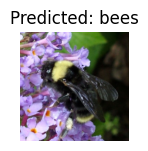

In [ ]:
# Visualize model performance
visualize_model(model_conv)

In [ ]:
# Predict on a specific image
img_path = os.path.join(data_dir, 'val', 'bees', 'bees2.jpg')

if not os.path.exists(img_path):
    print(f"Error: File not found at {img_path}")
    print("Files in the directory:")
    try:
        print(os.listdir(os.path.join(data_dir, 'val', 'bees')))
    except FileNotFoundError:
        print(f"Error: Directory not found at {os.path.join(data_dir, 'val', 'bees')}")
else:
    visualize_model_predictions(model_conv, img_path)

Error: File not found at /content/hymenoptera/hymenoptera/val/bees/bees2.jpg
Files in the directory:
['586474709_ae436da045.jpg', '2709775832_85b4b50a57.jpg', '400262091_701c00031c.jpg', '2438480600_40a1249879.jpg', '456097971_860949c4fc.jpg', '2060668999_e11edb10d0.jpg', '2321144482_f3785ba7b2.jpg', '10870992_eebeeb3a12.jpg', '2809496124_5f25b5946a.jpg', '1519368889_4270261ee3.jpg', '26589803_5ba7000313.jpg', '2741763055_9a7bb00802.jpg', '2103637821_8d26ee6b90.jpg', '2841437312_789699c740.jpg', '2086294791_6f3789d8a6.jpg', '1328423762_f7a88a8451.jpg', '44105569_16720a960c.jpg', '464594019_1b24a28bb1.jpg', '57459255_752774f1b2.jpg', '416144384_961c326481.jpg', '2883093452_7e3a1eb53f.jpg', '2525379273_dcb26a516d.jpg', '1355974687_1341c1face.jpg', '149973093_da3c446268.jpg', '2751836205_6f7b5eff30.jpg', '3077452620_548c79fda0.jpg', '2501530886_e20952b97d.jpg', '2173503984_9c6aaaa7e2.jpg', '2478216347_535c8fe6d7.jpg', '2782079948_8d4e94a826.jpg', '350436573_41f4ecb6c8.jpg', '151594775_ee7

In [ ]:
plt.ioff()
plt.show()